# Essentia EmoMusic — Mood Prediction Benchmark

Evaluates the **production Essentia pipeline** (`TensorflowPredictMusiCNN` → EmoMusic regression)
on three annotated datasets and five qualitative spot-checks.

> **Run this notebook in its own Colab runtime** — do not mix with `02_music2emo_benchmark.ipynb`.
> Essentia pins numpy ~1.x; the two environments are incompatible in the same kernel.

### Sections
0. Environment setup
1. Shared evaluation utilities
2. Essentia model files
3. Predictor
4. Datasets
5. Evaluation
6. Qualitative spot-checks
7. Profiling
8. Summary

## 0. Environment Setup

In [1]:
!pip install essentia-tensorflow yt-dlp librosa matplotlib pandas scipy tqdm gdown -q
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 72.3 MB/s eta 0:00:00
Setup complete.


## 1. Shared Evaluation Utilities

In [2]:
import os, sys

# REPO_BRANCH: update to "main" after the PR is merged
REPO_BRANCH = "feat/mood-model-benchmark"

if not os.path.exists("eval_datasets.py"):
    REPO = "Soundtrack-Mood-Manager"
    if not os.path.exists(REPO):
        !git clone --depth 1 --branch {REPO_BRANCH} https://github.com/francescovidaich964/Soundtrack-Mood-Manager.git
    sys.path.insert(0, f"{REPO}/evaluation")

from eval_datasets import setup_deam, setup_emomusic, setup_pmemo, setup_merge
from metrics import compute_metrics, print_metrics
from visualization import plot_scatter, cross_dataset_comparison
from spot_checks import SPOT_CHECKS, download_spot_checks, run_evaluation, profile_predictor

from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

DATA_DIR      = Path("data")
MODELS_DIR    = Path("models")
SPOTCHECK_DIR = Path("spotchecks")
for d in [DATA_DIR, MODELS_DIR, SPOTCHECK_DIR]:
    d.mkdir(exist_ok=True)

MODEL_TAG = "essentia"
print("Imports complete.")

Cloning into 'Soundtrack-Mood-Manager'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 43 (delta 1), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 62.01 KiB | 4.13 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Imports complete.


## 2. Download Essentia Model Files

Same `.pb` files used by the production sync pipeline.

In [3]:
MODEL_URLS = {
    "msd-musicnn-1.pb":
        "https://essentia.upf.edu/models/feature-extractors/musicnn/msd-musicnn-1.pb",
    "emomusic-msd-musicnn-2.pb":
        "https://essentia.upf.edu/models/classification-heads/emomusic/emomusic-msd-musicnn-2.pb",
}

for name, url in MODEL_URLS.items():
    dest = MODELS_DIR / name
    if dest.exists():
        print(f"  ✓ {name} ({dest.stat().st_size/1e6:.1f} MB, cached)")
        continue
    print(f"Downloading {name}...", end=" ", flush=True)
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(dest, "wb") as f:
        for chunk in r.iter_content(65536):
            f.write(chunk)
    print(f"{dest.stat().st_size/1e6:.1f} MB")

## 3. Predictor

In [4]:
class EssentiaPredictor:
    """Production pipeline: MusiCNN embeddings → EmoMusic valence/arousal regression.

    Mirrors src/feature_extractor.py; inlined here so the notebook is self-contained.

    NOTE ON GPU: essentia-tensorflow is compiled CPU-only (no GPU wheels on PyPI).
    Selecting a GPU runtime in Colab does not accelerate this notebook.
    The main lever for speed is batchSize: it controls how many audio patches
    are processed per TF call, improving CPU throughput on longer clips.
    """

    def __init__(self, models_dir: Path, batch_size: int = 256):
        import essentia
        essentia.log.warningActive = False
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            from essentia.standard import MonoLoader, TensorflowPredictMusiCNN, TensorflowPredict2D
        self._MonoLoader = MonoLoader
        self._musicnn = TensorflowPredictMusiCNN(
            graphFilename=str(models_dir / "msd-musicnn-1.pb"),
            output="model/dense/BiasAdd",
            batchSize=batch_size,
        )
        self._emomusic = TensorflowPredict2D(
            graphFilename=str(models_dir / "emomusic-msd-musicnn-2.pb"),
            output="model/Identity",
            batchSize=batch_size,
        )
        print(f"EssentiaPredictor ready (CPU, batchSize={batch_size}).")

    def predict(self, audio_path) -> dict | None:
        """Returns {'valence': float, 'arousal': float} in [0, 1], or None on failure."""
        try:
            audio = self._MonoLoader(filename=str(audio_path), sampleRate=16000)()
            embeddings = self._musicnn(audio)
            if embeddings.shape[0] == 0:
                return None
            preds = self._emomusic(embeddings)
            if preds.shape[0] == 0:
                return None
            mean = preds.mean(axis=0)
            valence = float(np.clip((mean[0] - 1.0) / 8.0, 0.0, 1.0))
            arousal = float(np.clip((mean[1] - 1.0) / 8.0, 0.0, 1.0))
            if not (math.isfinite(valence) and math.isfinite(arousal)):
                return None
            return {"valence": valence, "arousal": arousal}
        except Exception:
            return None


predictor = EssentiaPredictor(MODELS_DIR)

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


EssentiaPredictor ready (CPU, batchSize=256).


[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/msd-musicnn-1.pb`
[   INFO   ] TensorflowPredict: Successfully loaded graph file: `models/emomusic-msd-musicnn-2.pb`


## 4. Datasets

Annotations are downloaded automatically where possible.
See the printed instructions for datasets that require manual setup.

In [5]:
df_deam,     deam_id, deam_val, deam_aro = setup_deam(DATA_DIR,  download_audio=True)
df_emomusic, em_id,   em_val,   em_aro   = setup_emomusic(DATA_DIR)
df_pmemo,    pm_id,   pm_val,   pm_aro   = setup_pmemo(DATA_DIR)
df_merge,    mg_id,   mg_val,   mg_aro   = setup_merge(DATA_DIR, download_audio=True)

Extracting DEAM_Annotations.zip...
Extracting DEAM_audio.zip...
DEAM: 1802 songs  id='song_id'  valence='valence_mean'  arousal='arousal_mean'
⚠  EmoMusic unavailable — official download links return 404 (as of 2025-06).
   If you have a local copy, place annotations.csv in data/emomusic/
   and audio .mp3 files in data/emomusic/clips/


Retrieving folder contents


Processing file 1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ PMEmo2019.zip
Processing file 1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq README.txt


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ
From (redirected): https://drive.google.com/uc?id=1UzC3NCDj30j9Ba7i5lkMzWO5gFqSr0OJ&confirm=t&uuid=a1fa61d2-e65d-4d55-96e6-efef0697a1da
To: /kaggle/working/data/pmemo/PMEmo2019.zip
100%|██████████| 680M/680M [00:05<00:00, 117MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KQ0zjRiBQynnHyVPU7DGpUWvtPmCBOcq
To: /kaggle/working/data/pmemo/README.txt
100%|██████████| 1.52k/1.52k [00:00<00:00, 1.61MB/s]
Download completed


Extracting PMEmo2019.zip...
PMEmo: 767 rows  id='musicId'  valence='Valence(mean)'  arousal='Arousal(mean)'
Extracting MERGE_Audio_Balanced.zip...
MERGE: 3232 rows  id='Song'  valence='Valence'  arousal='Arousal'


## 5. Evaluation

Set the audio directory paths below, then run the evaluation loop.
Datasets without audio are skipped automatically.

In [6]:
# DEAM audio extracts to MEMD_audio/ — find it wherever it landed
_deam_audio   = next(iter(sorted((DATA_DIR / "deam").rglob("MEMD_audio"))), None)
DEAM_AUDIO    = _deam_audio if _deam_audio else DATA_DIR / "deam" / "MEMD_audio"
if _deam_audio:
    print(f"DEAM audio  : {DEAM_AUDIO}")

EMOMUSIC_AUDIO = DATA_DIR / "emomusic" / "clips"

_pmemo_chorus = next(iter(sorted((DATA_DIR / "pmemo").rglob("chorus"))), None)
PMEMO_AUDIO   = _pmemo_chorus if _pmemo_chorus else DATA_DIR / "pmemo" / "chorus"
if _pmemo_chorus:
    print(f"PMEmo audio : {PMEMO_AUDIO}")

_merge_root   = next(iter(sorted((DATA_DIR / "merge").rglob("MERGE_Audio_Balanced"))), None)
MERGE_AUDIO   = _merge_root if _merge_root else DATA_DIR / "merge" / "MERGE_Audio_Balanced"
if _merge_root:
    print(f"MERGE audio : {MERGE_AUDIO}")

# ── Speed note ────────────────────────────────────────────────────────────────
# essentia-tensorflow is CPU-only regardless of runtime type.
# Selecting a T4 GPU in Colab does NOT help here.
# Speed is controlled by batchSize in EssentiaPredictor (set above to 256).
# At ~4 s/track on CPU: DEAM ~2 h, PMEmo ~50 min, MERGE ~3.5 h.
MAX_TRACKS = None  # set to e.g. 200 for a quick sanity check

DATASETS = [
    ("DEAM",     df_deam,     DEAM_AUDIO,     deam_id, deam_val, deam_aro),
    ("EmoMusic", df_emomusic, EMOMUSIC_AUDIO, em_id,   em_val,   em_aro),
    ("PMEmo",    df_pmemo,    PMEMO_AUDIO,    pm_id,   pm_val,   pm_aro),
    ("MERGE",    df_merge,    MERGE_AUDIO,    mg_id,   mg_val,   mg_aro),
]

all_results = {}
for ds_name, df_a, audio_dir, id_col, val_col, aro_col in DATASETS:
    if df_a is None or not audio_dir.exists():
        print(f"Skipping {ds_name} — audio not found at {audio_dir}")
        continue
    all_results[ds_name] = run_evaluation(
        ds_name, MODEL_TAG, predictor.predict,
        audio_dir, df_a, id_col, val_col, aro_col, MAX_TRACKS,
    )

DEAM audio  : data/deam/MEMD_audio
PMEmo audio : data/pmemo/PMEmo2019/chorus
MERGE audio : data/merge/MERGE_Audio_Balanced


DEAM / essentia:   0%|          | 0/1802 [00:00<?, ?it/s]

DEAM: 1802 tracks  |  OK: 1802  |  failed: 0
Skipping EmoMusic — audio not found at data/emomusic/clips


PMEmo / essentia:   0%|          | 0/794 [00:00<?, ?it/s]

PMEmo: 767 tracks  |  OK: 767  |  failed: 0


MERGE / essentia:   0%|          | 0/3232 [00:00<?, ?it/s]

MERGE: 3232 tracks  |  OK: 3232  |  failed: 0



── DEAM ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0913 0.3801    0.6200    0.4593
    arousal 1802 0.0906 0.4726    0.6965    0.5303


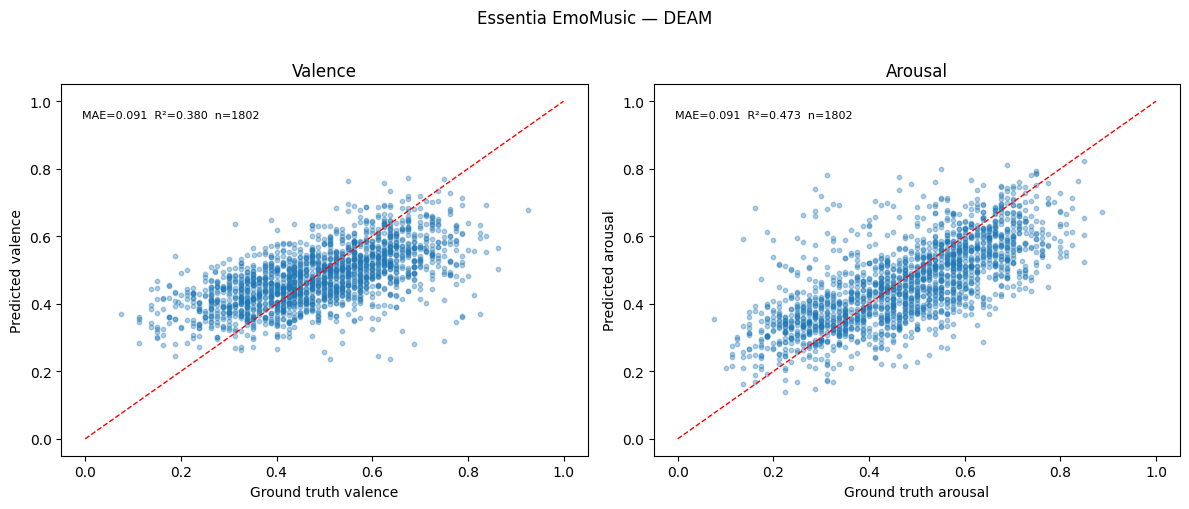

Saved: essentia_emomusic_—_deam.png

── PMEmo ──
  PMEmo:
        Dim   n    MAE     R² Pearson r Kendall τ
    valence 767 0.1238 0.1499    0.5749    0.4123
    arousal 767 0.1076 0.4897    0.7455    0.5435


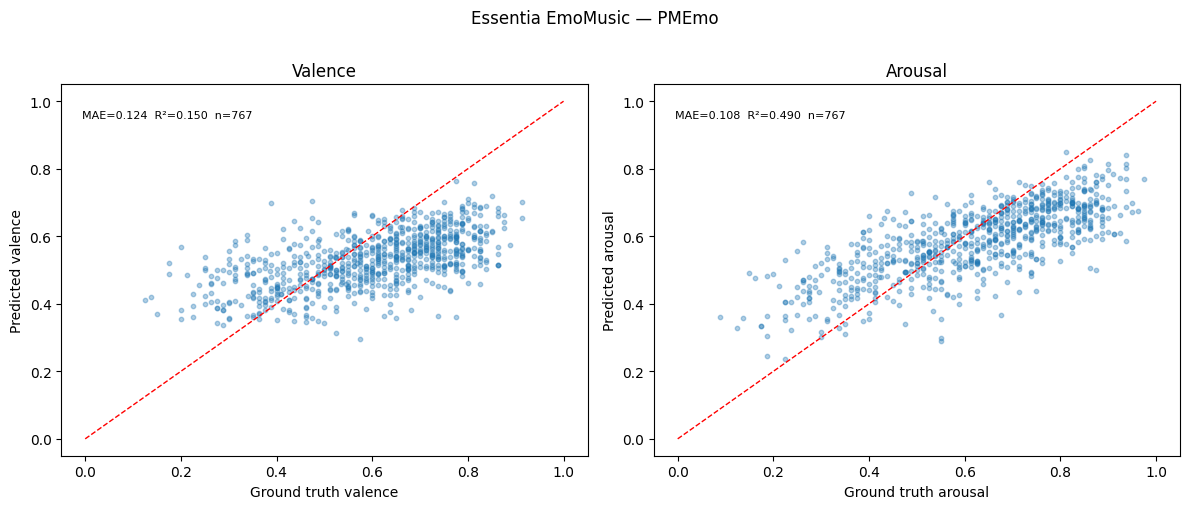

Saved: essentia_emomusic_—_pmemo.png

── MERGE ──
  MERGE:
        Dim    n    MAE      R² Pearson r Kendall τ
    valence 3232 0.1843  0.1189    0.3857    0.2584
    arousal 3232 0.1108 -0.0127    0.6246    0.4399


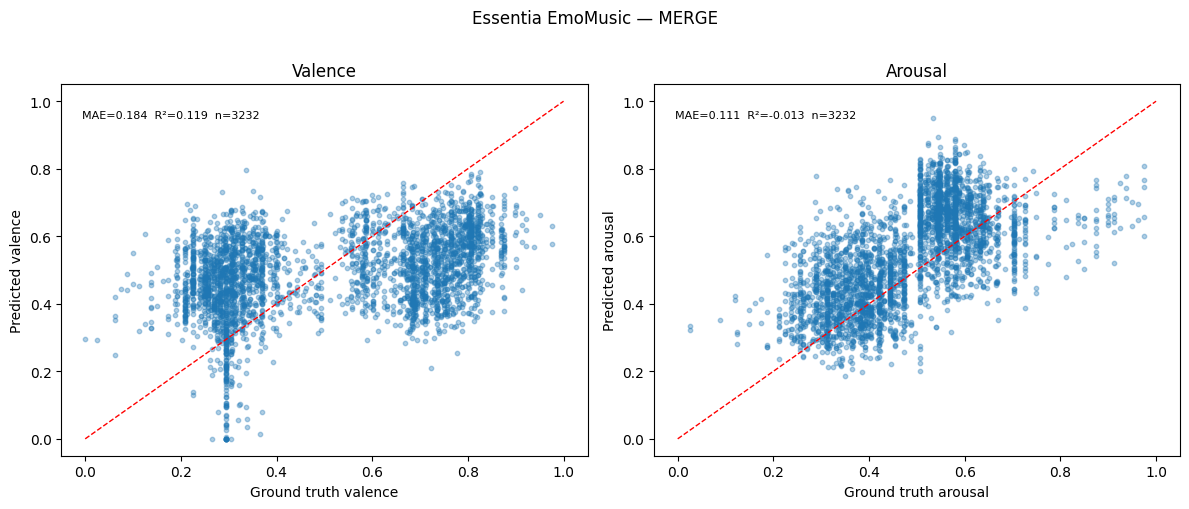

Saved: essentia_emomusic_—_merge.png


In [7]:
# Metrics and scatter plots per dataset
for ds_name, df in all_results.items():
    print_metrics(df, ds_name)
    plot_scatter(df, f"Essentia EmoMusic — {ds_name}")

In [8]:
# Save all results to CSV so they can be compared with the music2emo notebook
if all_results:
    combined = pd.concat(all_results.values())
    out = f"{MODEL_TAG}_results.csv"
    combined.to_csv(out, index=False)
    print(f"Saved: {out}  ({len(combined)} rows)")
else:
    print("No results to save — check that audio directories exist.")

Saved: essentia_results.csv  (5801 rows)


## 6. Qualitative Spot-checks

Five well-known tracks spanning all four mood quadrants, downloaded via `yt-dlp`.

In [9]:
download_spot_checks(SPOTCHECK_DIR)

In [10]:
spot_rows = []
for track in SPOT_CHECKS:
    audio = SPOTCHECK_DIR / f"{track['title']}.mp3"
    if not audio.exists():
        print(f"  ✗ {track['title']} — not found, skipping")
        continue
    pred = predictor.predict(audio)
    spot_rows.append({
        "title":       track["title"].replace("_", " "),
        "exp_valence": track["exp_valence"],
        "exp_arousal": track["exp_arousal"],
        "valence":     pred["valence"] if pred else float("nan"),
        "arousal":     pred["arousal"] if pred else float("nan"),
    })
    name = track["title"].replace("_", " ").title()
    print(f"\n{name}")
    print(f"  Expected:  v={track['exp_valence']:.2f}  a={track['exp_arousal']:.2f}")
    if pred:
        print(f"  Predicted: v={pred['valence']:.2f}  a={pred['arousal']:.2f}")
    else:
        print("  Predicted: FAILED")

spot_df = pd.DataFrame(spot_rows)
print(f"\nCompleted {len(spot_df)} spot-checks.")


Dont Stop Me Now
  Expected:  v=0.90  a=0.95
  Predicted: v=0.57  a=0.59

Clair De Lune
  Expected:  v=0.70  a=0.10
  Predicted: v=0.39  a=0.35

Killing In The Name
  Expected:  v=0.30  a=0.95
  Predicted: v=0.64  a=0.70

Hurt Johnny Cash
  Expected:  v=0.10  a=0.15
  Predicted: v=0.42  a=0.38

Walking On Sunshine
  Expected:  v=0.95  a=0.85
  Predicted: v=0.60  a=0.62

Completed 5 spot-checks.


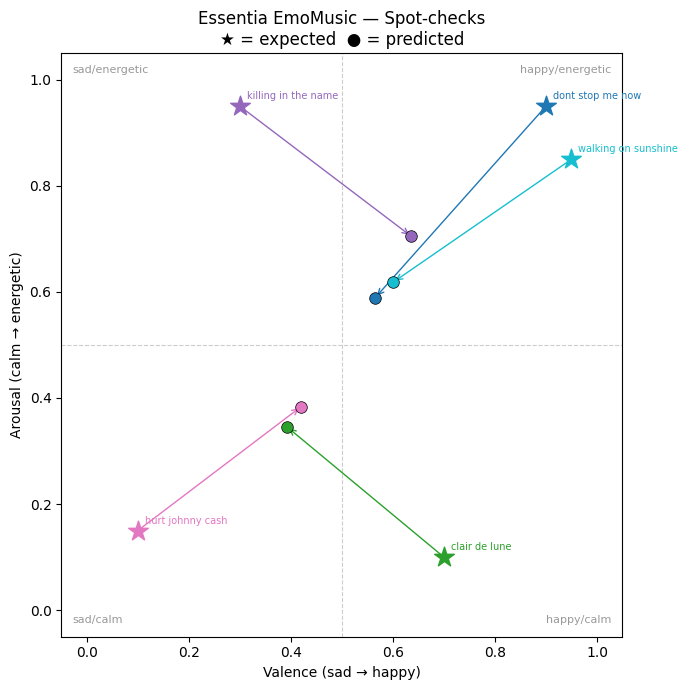

In [11]:
if not spot_df.empty:
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(spot_df)))
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color="#ccc", lw=0.8, ls="--"); ax.axvline(0.5, color="#ccc", lw=0.8, ls="--")
    ax.text(0.02, 0.98, "sad/energetic",   transform=ax.transAxes, va="top",    fontsize=8, color="#999")
    ax.text(0.98, 0.98, "happy/energetic",  transform=ax.transAxes, va="top",    ha="right", fontsize=8, color="#999")
    ax.text(0.02, 0.02, "sad/calm",         transform=ax.transAxes, va="bottom", fontsize=8, color="#999")
    ax.text(0.98, 0.02, "happy/calm",       transform=ax.transAxes, va="bottom", ha="right", fontsize=8, color="#999")
    for i, row in spot_df.iterrows():
        c = colors[i]
        ax.scatter(row["exp_valence"], row["exp_arousal"], marker="*", s=220, color=c, zorder=4)
        if not pd.isna(row["valence"]):
            ax.scatter(row["valence"], row["arousal"], marker="o", s=70,
                       color=c, edgecolors="black", lw=0.5, zorder=4)
            ax.annotate("", xy=(row["valence"], row["arousal"]),
                        xytext=(row["exp_valence"], row["exp_arousal"]),
                        arrowprops=dict(arrowstyle="->", color=c, lw=1.0))
        ax.annotate(row["title"], xy=(row["exp_valence"], row["exp_arousal"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=7, color=c)
    ax.set_xlabel("Valence (sad → happy)")
    ax.set_ylabel("Arousal (calm → energetic)")
    ax.set_title("Essentia EmoMusic — Spot-checks\n★ = expected  ● = predicted")
    plt.tight_layout()
    plt.savefig(f"{MODEL_TAG}_spotchecks.png", dpi=120, bbox_inches="tight")
    plt.show()

## 7. Runtime & Memory Profiling

`tracemalloc` measures Python heap allocations only.

In [12]:
test_audio = next(
    (SPOTCHECK_DIR / f"{t['title']}.mp3" for t in SPOT_CHECKS
     if (SPOTCHECK_DIR / f"{t['title']}.mp3").exists()),
    None,
)

if test_audio is None:
    print("No audio for profiling — run Section 6 first.")
else:
    prof = profile_predictor(predictor.predict, test_audio, n=5)
    print(f"Essentia EmoMusic — profiling on {test_audio.name}:")
    print(f"  Mean: {prof['mean_s']:.2f} s/track")
    print(f"  Std:  {prof['std_s']:.3f} s")
    print(f"  Peak RAM: {prof['peak_mb']:.1f} MB")

Essentia EmoMusic — profiling on dont_stop_me_now.mp3:
  Mean: 14.17 s/track
  Std:  0.491 s
  Peak RAM: 0.1 MB


## 8. Summary

In [13]:
print("=" * 60)
print("ESSENTIA EMOMUSIC — BENCHMARK SUMMARY")
print("=" * 60)

print("\n── Dataset metrics ──")
if all_results:
    combined = pd.concat(all_results.values())
    print_metrics(combined, "all datasets")
else:
    print("  (no datasets evaluated)")

print("\n── Spot-checks ──")
if not spot_df.empty:
    print(spot_df[["title", "exp_valence", "exp_arousal", "valence", "arousal"]]
          .to_string(index=False, float_format="{:.2f}".format))
else:
    print("  (none run)")

print("\n── Runtime ──")
if "prof" in dir():
    print(f"  {prof['mean_s']:.2f} s/track  (peak RAM {prof['peak_mb']:.1f} MB)")
else:
    print("  (run Section 7 to profile)")

print("\n" + "=" * 60)

ESSENTIA EMOMUSIC — BENCHMARK SUMMARY

── Dataset metrics ──

── all datasets ──
  DEAM:
        Dim    n    MAE     R² Pearson r Kendall τ
    valence 1802 0.0913 0.3801    0.6200    0.4593
    arousal 1802 0.0906 0.4726    0.6965    0.5303
  MERGE:
        Dim    n    MAE      R² Pearson r Kendall τ
    valence 3232 0.1843  0.1189    0.3857    0.2584
    arousal 3232 0.1108 -0.0127    0.6246    0.4399
  PMEmo:
        Dim   n    MAE     R² Pearson r Kendall τ
    valence 767 0.1238 0.1499    0.5749    0.4123
    arousal 767 0.1076 0.4897    0.7455    0.5435

── Spot-checks ──
              title  exp_valence  exp_arousal  valence  arousal
   dont stop me now         0.90         0.95     0.57     0.59
      clair de lune         0.70         0.10     0.39     0.35
killing in the name         0.30         0.95     0.64     0.70
   hurt johnny cash         0.10         0.15     0.42     0.38
walking on sunshine         0.95         0.85     0.60     0.62

── Runtime ──
  14.17 s/track 